# Task 4 — LSTM Gating Mechanism Breakdown

### Solving the Memory Decay Problem: The LSTM Highway
To solve the vanishing gradient problem, Hochreiter & Schmidhuber (1997) introduced the **Long Short-Term Memory (LSTM)** architecture. The core innovation of the LSTM is the **Cell State ($C_t$)** — a dedicated memory highway that runs straight through the sequence with only minor linear modifications.

![LSTM Architecture](outputs/LSTM-chain.png)

Instead of forcing information to undergo active matrix multiplication at each step, the LSTM regulates the cell state using three specialized multiplicative "gates" that scale values between $0.0$ (block/erase) and $1.0$ (keep/write):

1. **Forget Gate ($f_t$)**: Decides what information in the cell state memory is no longer relevant and should be erased.
2. **Input Gate ($i_t$)**: Decides what new incoming information is important and should be added to the cell state memory.
3. **Output Gate ($o_t$)**: Decides what parts of the updated cell state memory should be output as the hidden state ($h_t$) for the current step's prediction.

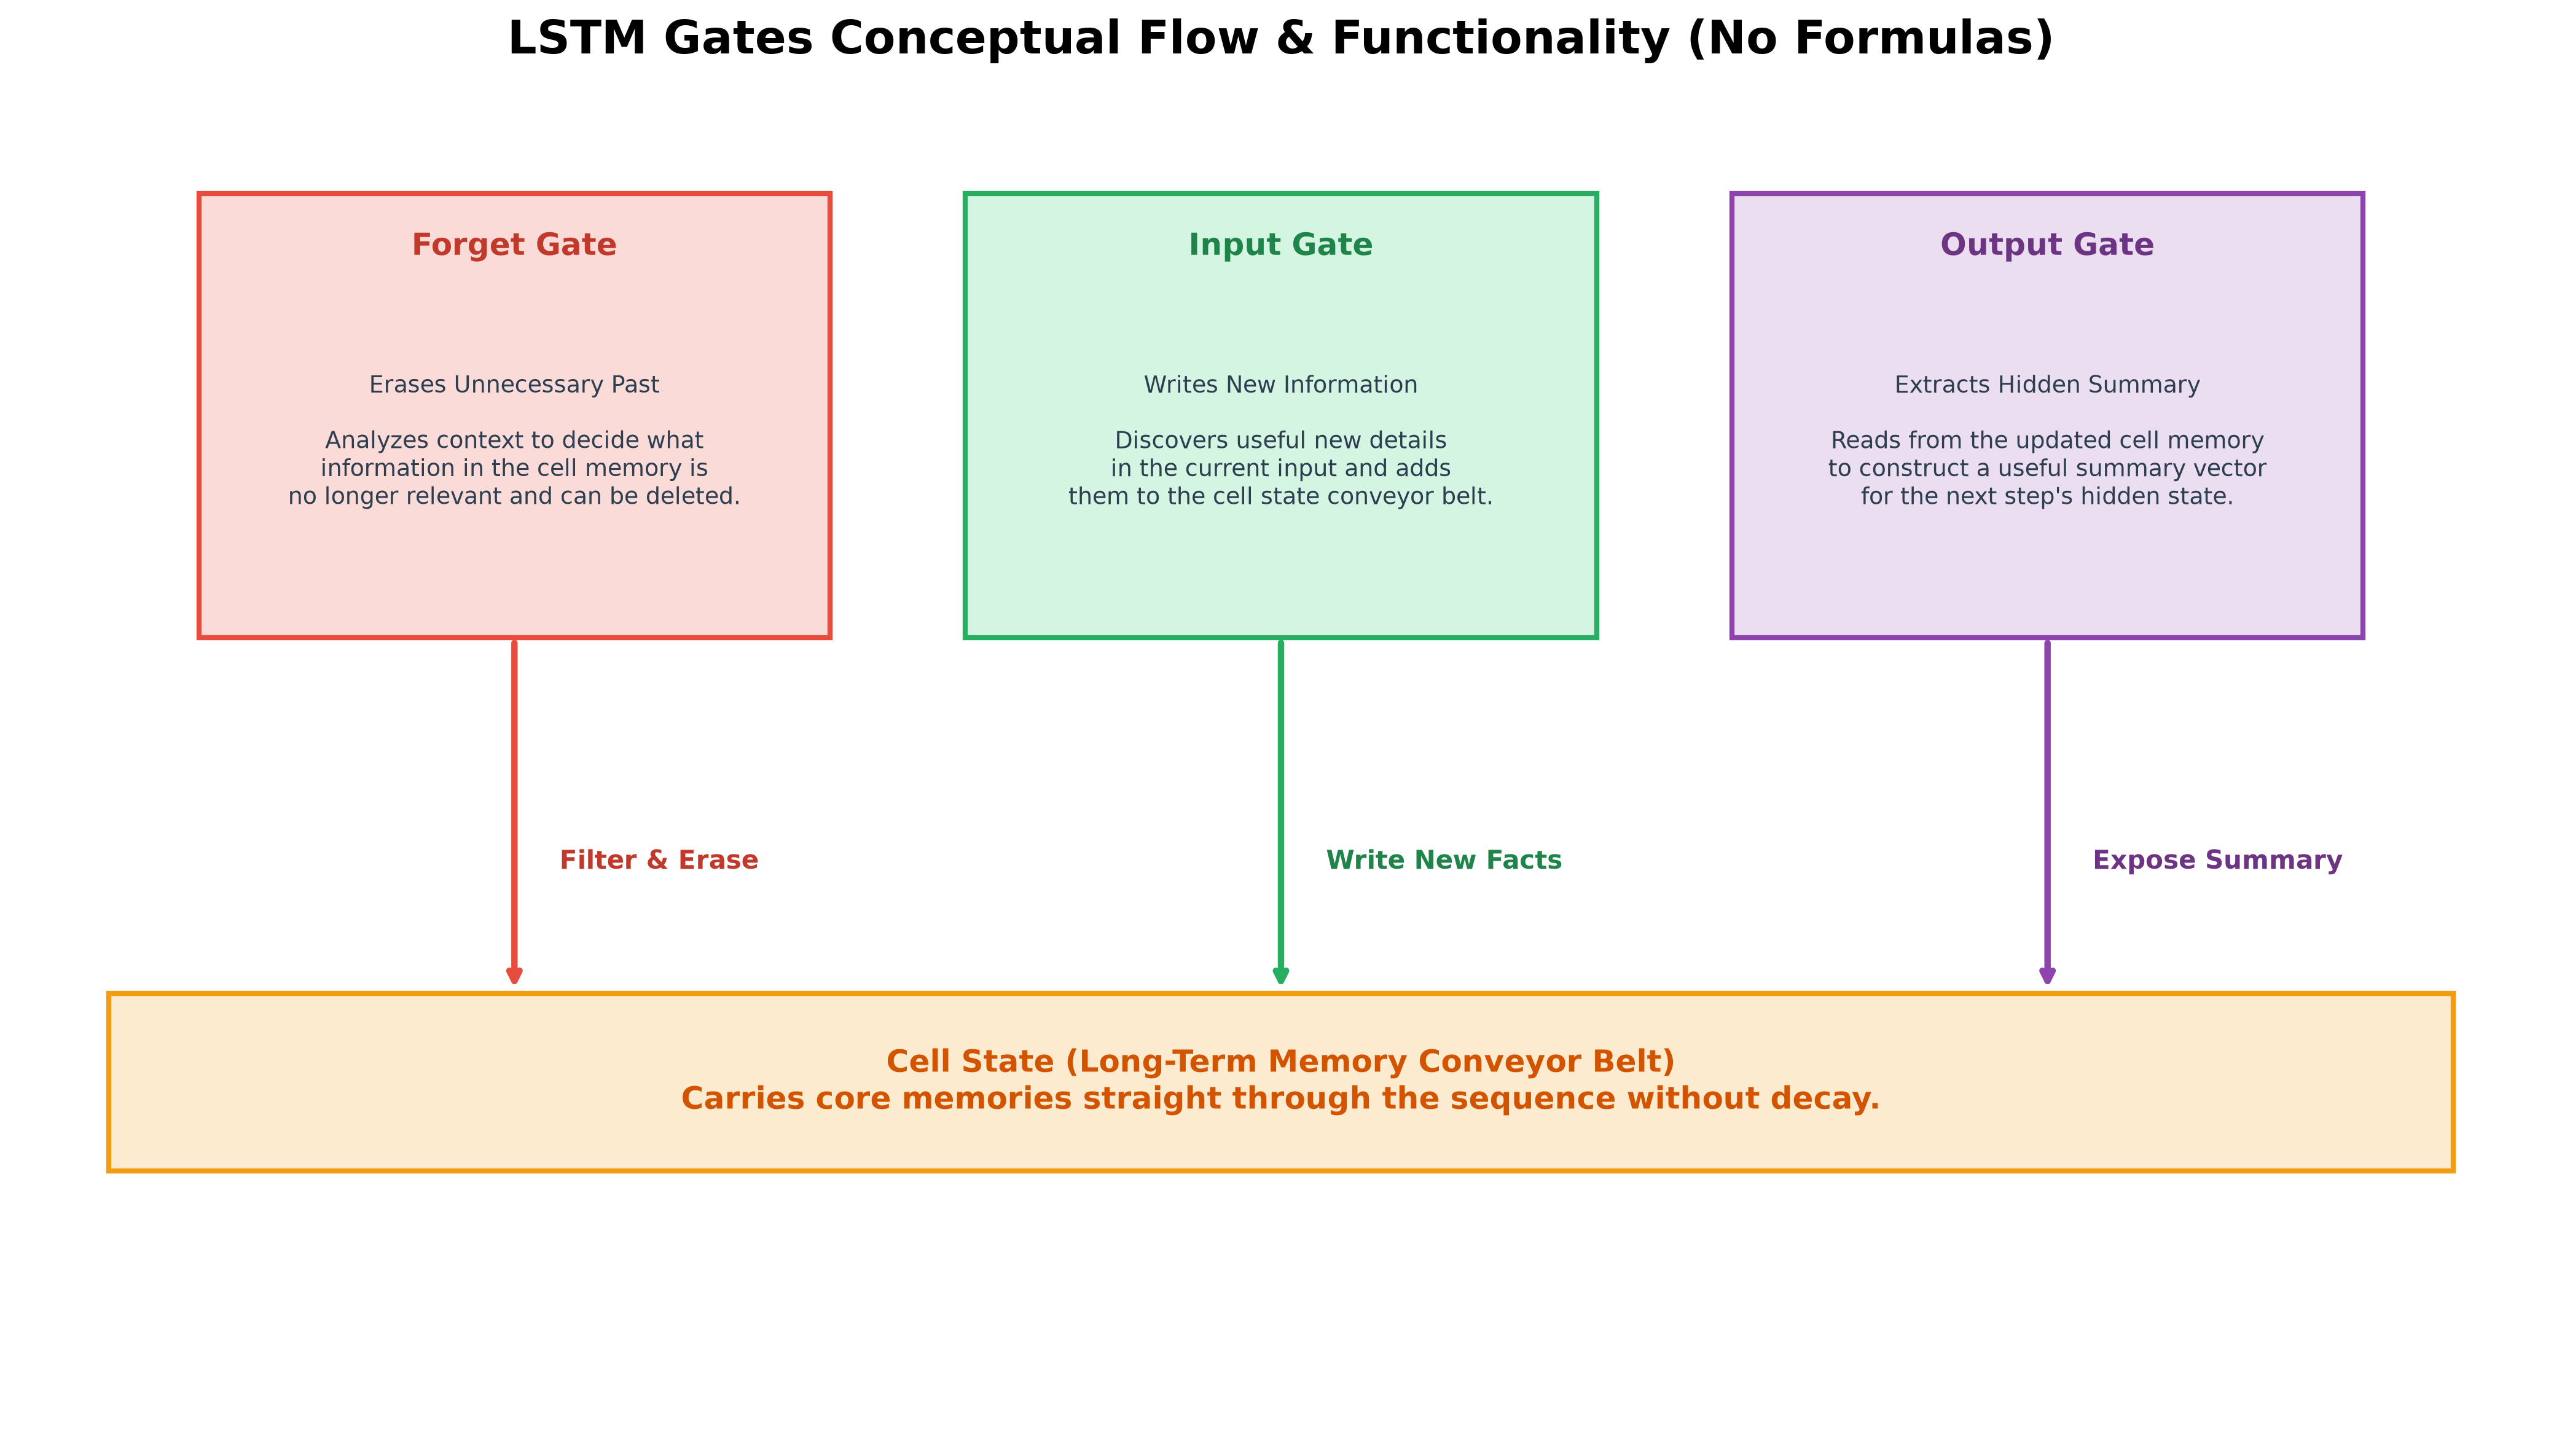

---

### Gated States from Scratch
We implement the equations of these gates in NumPy, tracing how the hidden state and cell state cooperate to keep memory signals alive over long sequences.

### Step 1 — Implement an LSTM Cell Step from Scratch

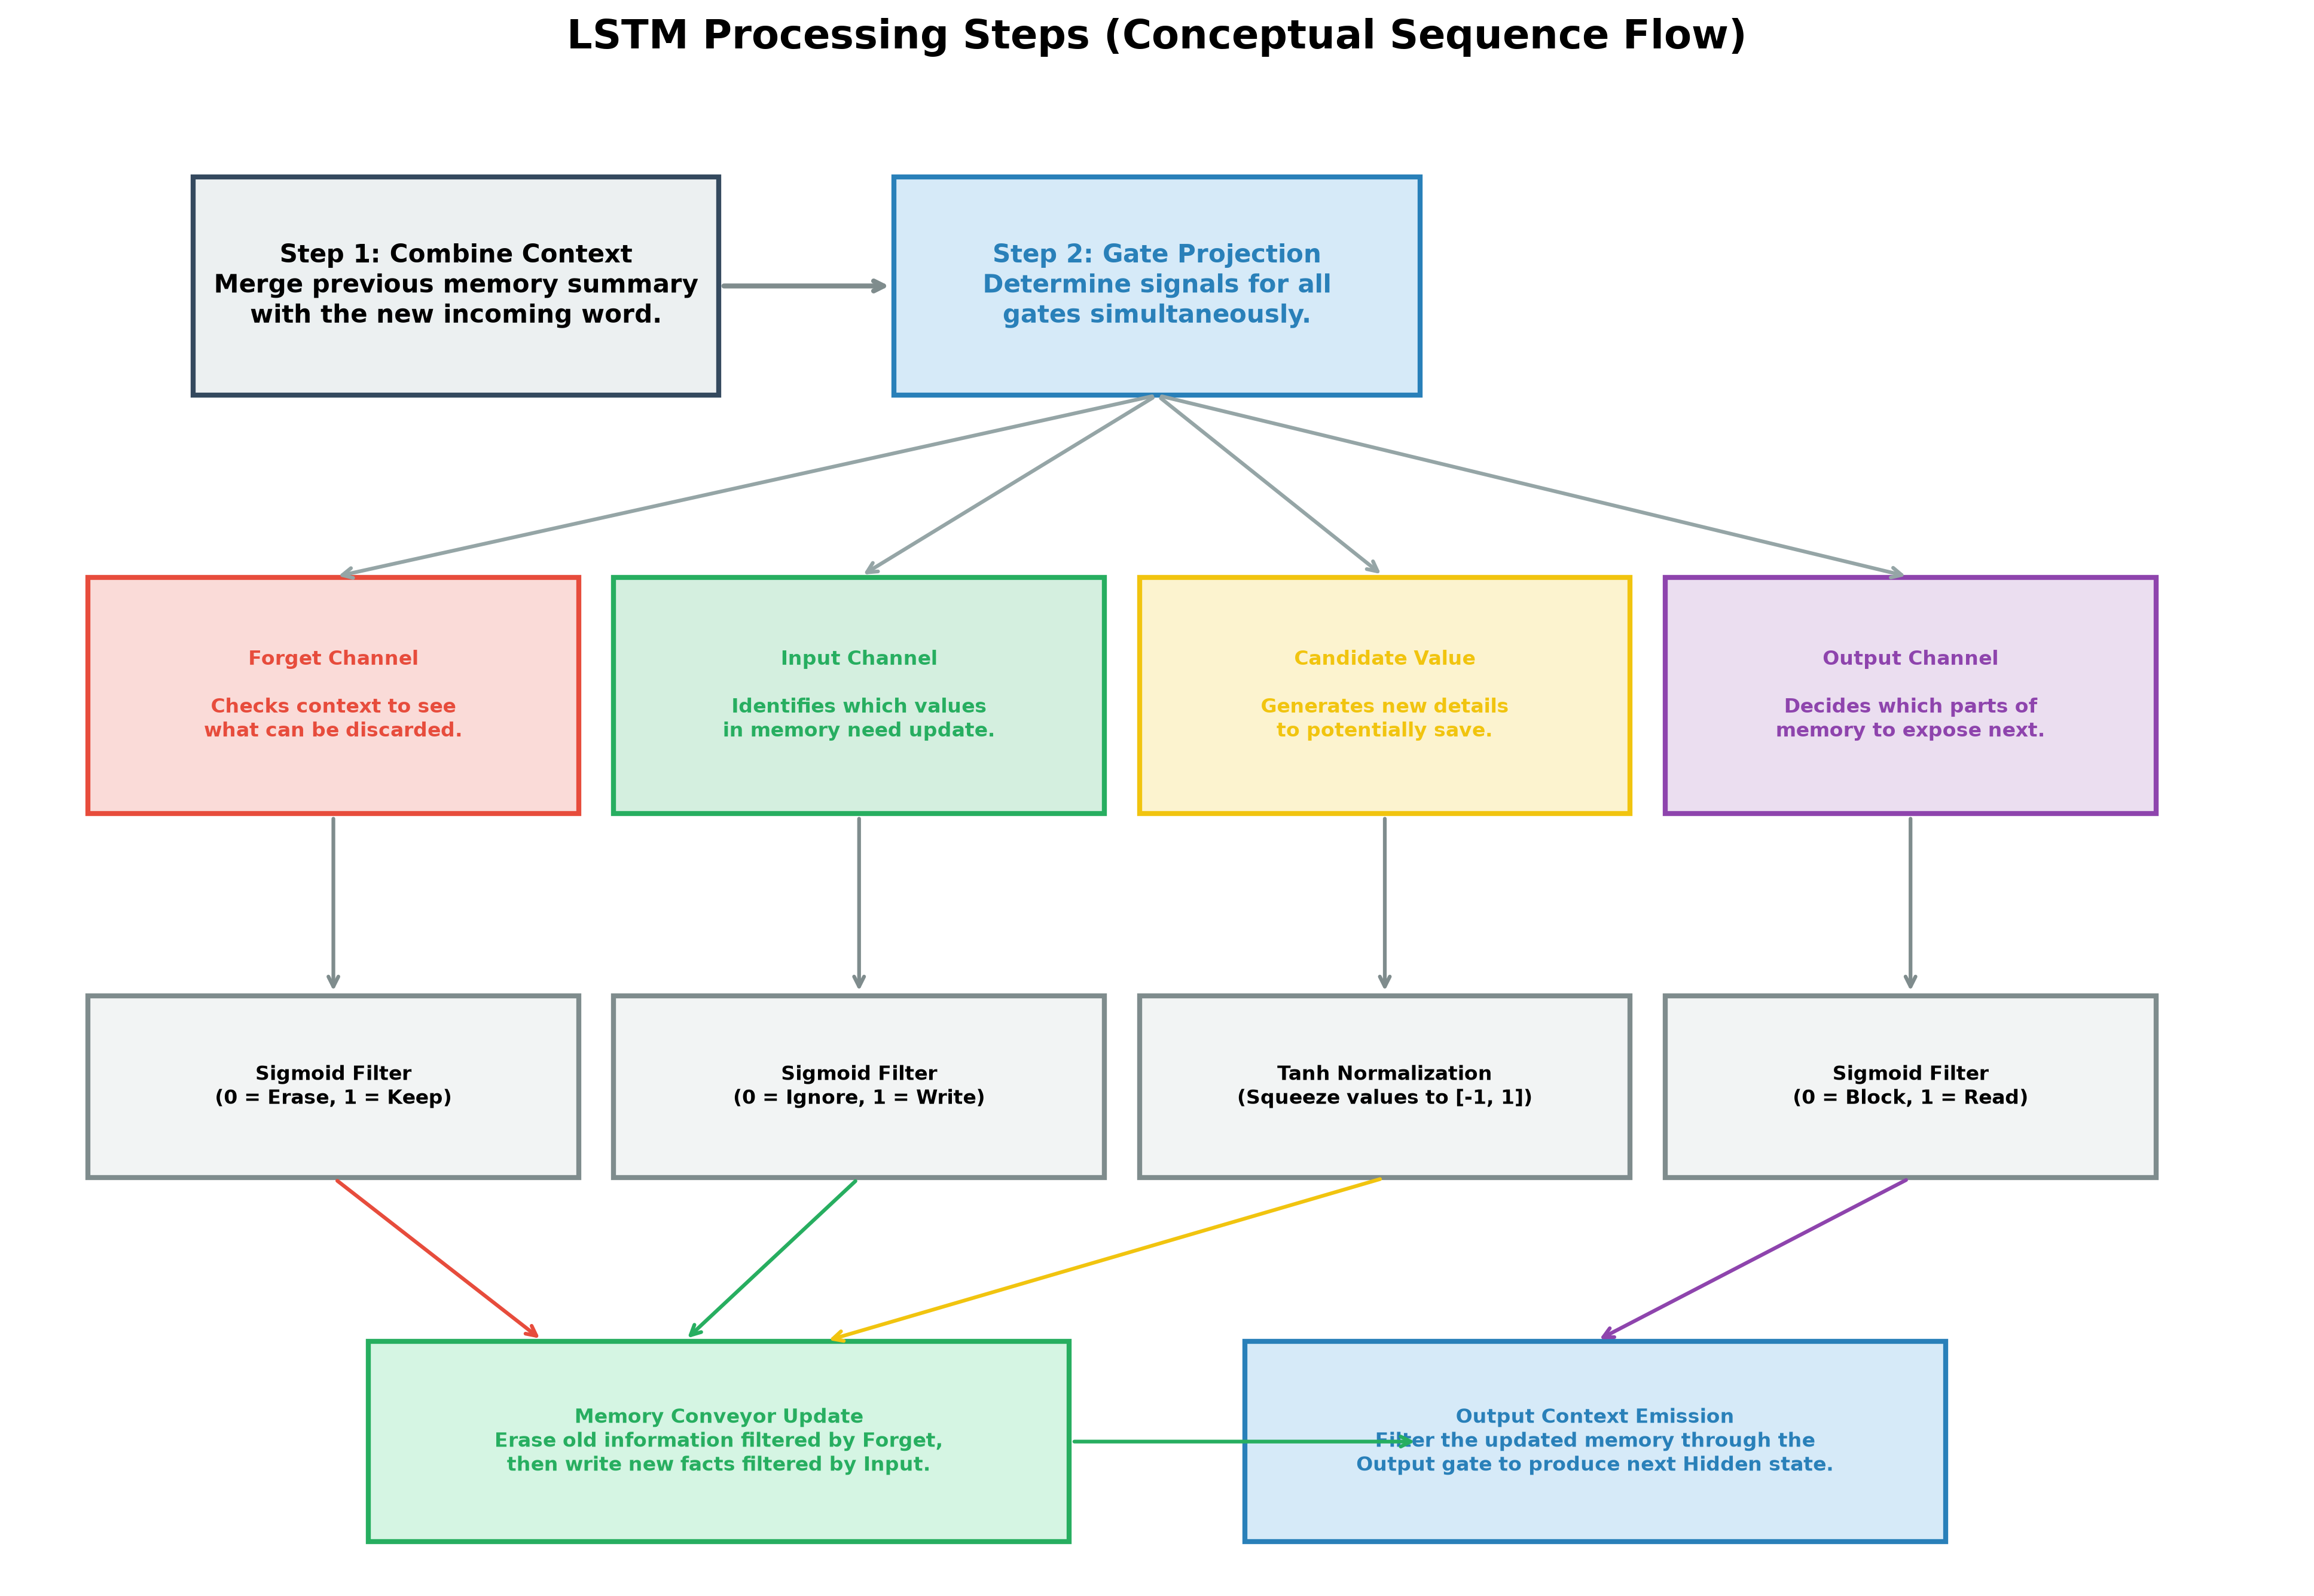



In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class LSTMCellScratch:
    def __init__(self, input_dim, hidden_dim):
        np.random.seed(42)
        self.hidden_dim = hidden_dim
        self.W = np.random.randn(4 * hidden_dim, input_dim + hidden_dim) * 0.1
        self.b = np.zeros((4 * hidden_dim, 1))
        
    def forward(self, x_t, h_prev, c_prev):
        concat = np.vstack((h_prev, x_t))
        gates = np.dot(self.W, concat) + self.b
        
        f_gate = gates[0:self.hidden_dim]
        i_gate = gates[self.hidden_dim:2*self.hidden_dim]
        c_tilde = gates[2*self.hidden_dim:3*self.hidden_dim]
        o_gate = gates[3*self.hidden_dim:]
        
        f_t = sigmoid(f_gate)
        i_t = sigmoid(i_gate)
        c_tilde_t = np.tanh(c_tilde)
        o_t = sigmoid(o_gate)
        
        c_t = f_t * c_prev + i_t * c_tilde_t
        h_t = o_t * np.tanh(c_t)
        
        return h_t, c_t, {
            'forget_gate': f_t,
            'input_gate': i_t,
            'candidate_cell': c_tilde_t,
            'output_gate': o_t
        }

# Instantiate cell
input_dim = 3
hidden_dim = 2
cell = LSTMCellScratch(input_dim, hidden_dim)

# Input parameters
x = np.array([[1.0, -0.5, 0.2]]).T
h_p = np.array([[0.1, -0.2]]).T
c_p = np.array([[0.5, 0.5]]).T

h_n, c_n, gate_vals = cell.forward(x, h_p, c_p)

print("LSTM Cell Forward Pass Outputs:")
print(f"  Forget Gate Output (f_t)   :\n{gate_vals['forget_gate']}")
print(f"  Input Gate Output (i_t)    :\n{gate_vals['input_gate']}")
print(f"  Candidate Cell State (~C_t):\n{gate_vals['candidate_cell']}")
print(f"  Updated Cell State (C_t)   :\n{c_n}")
print(f"  Output Gate Output (o_t)   :\n{gate_vals['output_gate']}")
print(f"  New Hidden State (h_t)     :\n{h_n}")



LSTM Cell Forward Pass Outputs:
  Forget Gate Output (f_t)   :
[[0.49791669]
 [0.51927613]]
  Input Gate Output (i_t)    :
[[0.52249538]
 [0.51579814]]
  Candidate Cell State (~C_t):
[[0.08606117]
 [0.08568632]]
  Updated Cell State (C_t)   :
[[0.29392491]
 [0.30383491]]
  Output Gate Output (o_t)   :
[[0.5062307 ]
 [0.46455799]]
  New Hidden State (h_t)     :
[[0.14465202]
 [0.13696013]]


### Step 2 — User-Defined Interactive Evaluation Function
Provide custom values for the inputs and previous states to calculate LSTM gate responses dynamically.


In [2]:
def evaluate_lstm_gates(input_vals, forget_bias=0.0):
    """
    User-defined evaluation function. Simulates LSTM gate logic under custom parameters.
    """
    x_input = np.array([input_vals]).T
    h_p = np.zeros((hidden_dim, 1))
    c_p = np.ones((hidden_dim, 1)) * 0.8
    
    temp_cell = LSTMCellScratch(len(input_vals), hidden_dim)
    temp_cell.b[0:hidden_dim] += forget_bias
    
    h_n, c_n, gates = temp_cell.forward(x_input, h_p, c_p)
    
    print(f"--- Evaluation for Input Vector: {input_vals} ---")
    print(f"Forget Bias Offset: {forget_bias}")
    print("-" * 50)
    print(f"Forget Gate values  : {gates['forget_gate'].flatten().round(4)}")
    print(f"Input Gate values   : {gates['input_gate'].flatten().round(4)}")
    print(f"Candidate Cell State: {gates['candidate_cell'].flatten().round(4)}")
    print(f"Updated Cell State  : {c_n.flatten().round(4)}")
    print(f"Output Gate values  : {gates['output_gate'].flatten().round(4)}")
    print(f"New Hidden State    : {h_n.flatten().round(4)}")

# Test with high forget bias (remembers old cell state)
evaluate_lstm_gates([1.0, 2.0, -1.0], forget_bias=5.0)
print("\n" + "="*60 + "\n")
# Test with low forget bias (wipes old cell state)
evaluate_lstm_gates([1.0, 2.0, -1.0], forget_bias=-5.0)



--- Evaluation for Input Vector: [1.0, 2.0, -1.0] ---
Forget Bias Offset: 5.0
--------------------------------------------------
Forget Gate values  : [0.9955 0.9928]
Input Gate values   : [0.4536 0.4978]
Candidate Cell State: [-0.2201 -0.0533]
Updated Cell State  : [0.6965 0.7677]
Output Gate values  : [0.4267 0.3819]
New Hidden State    : [0.257  0.2466]


--- Evaluation for Input Vector: [1.0, 2.0, -1.0] ---
Forget Bias Offset: -5.0
--------------------------------------------------
Forget Gate values  : [0.0099 0.0062]
Input Gate values   : [0.4536 0.4978]
Candidate Cell State: [-0.2201 -0.0533]
Updated Cell State  : [-0.0919 -0.0216]
Output Gate values  : [0.4267 0.3819]
New Hidden State    : [-0.0391 -0.0082]
